# Demo — pregled projekta

Kratka sveska koja pokazuje šta projekat radi, bez ponovnog treniranja.

Pokrenuti iz korena repoa, sa venv kernelom (`source .venv/bin/activate`, `TF_USE_LEGACY_KERAS=1`).

Težine: lokalno su `custom_vgglite` i `custom_hybrid`. Transfer modeli se skinu iz release-a `v1.0-models` (vidi README).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from PIL import Image as PILImage
from tensorflow import keras

ROOT = Path.cwd()
if not (ROOT / "experiments").is_dir():
    ROOT = Path.cwd().parent

sys.path.insert(0, str(ROOT / "src"))
from dataset import make_generators
from models import build_hybrid, build_vgglite

print("root:", ROOT)

I0000 00:00:1788554998.999815  285794 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788554999.062015  285794 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788555000.746869  285794 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


root: /home/anja/Desktop/ML/renaissance-to-pop-art-study


## 1. Uporedni rezultati (sačuvane metrike)

Vrednosti su iz `experiments/*/test_metrics.json` — isto što je u izveštaju.

,model,test_acc_%,macro_f1,params
0,vgglite,35.14,0.3302,1242674
1,hybrid,27.72,0.2383,57434
2,transfer_dense,49.93,0.4965,21839666
3,transfer_finetune,56.91,0.5704,21839666


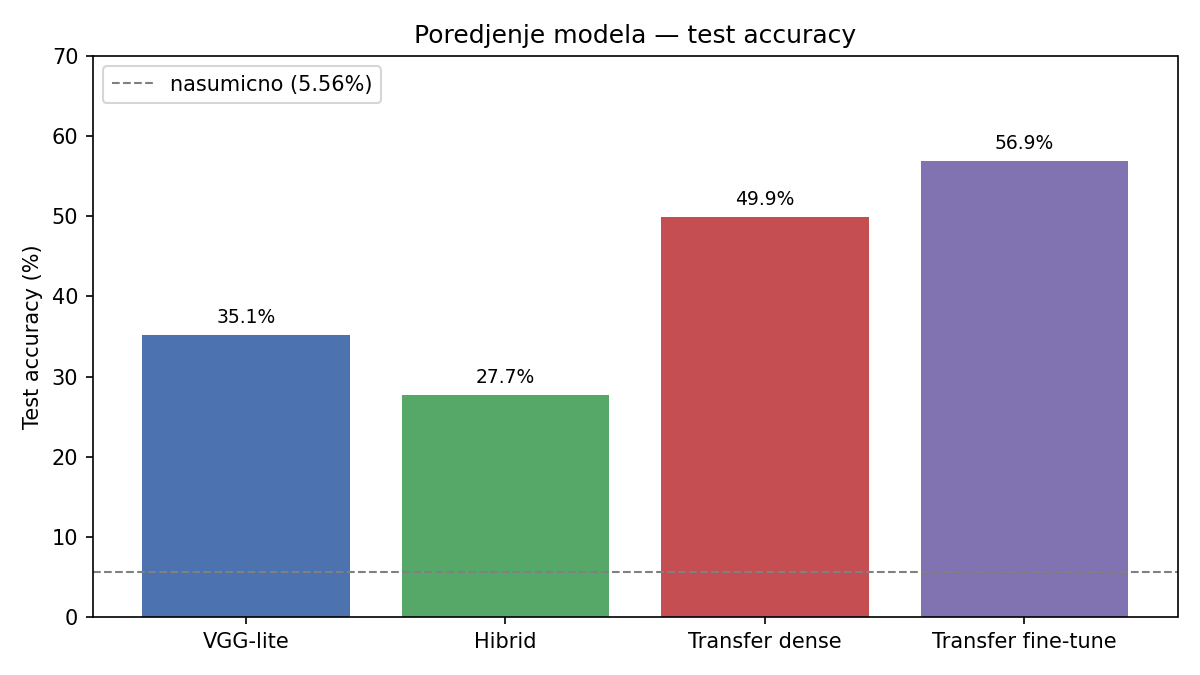

In [2]:
rows = []
for folder in ("custom_vgglite", "custom_hybrid", "transfer_dense", "transfer_finetune"):
    path = ROOT / "experiments" / folder / "test_metrics.json"
    with open(path) as f:
        m = json.load(f)
    rows.append({
        "model": m["model"],
        "test_acc_%": round(100 * m["test_accuracy"], 2),
        "macro_f1": round(m["macro_f1"], 4),
        "params": m["params"],
    })

df = pd.DataFrame(rows)
display(df)

bar = ROOT / "reports" / "figures" / "model_comparison_test_acc.png"
if bar.is_file():
    display(Image(filename=str(bar)))
else:
    print("nema bar chart — pokreni: python src/plot_comparison.py")

## 2. Učitavanje modela i predikcija

Podrazumevano: **VGG-lite** (težine su u repou lokalno).  
Za fine-tune promeni `MODEL_NAME` u `transfer_finetune` posle skidanja release-a.

In [3]:
MODEL_NAME = "vgglite"  # ili hybrid / transfer_dense / transfer_finetune
N_SHOW = 6

CUSTOM = {"vgglite": "custom_vgglite", "hybrid": "custom_hybrid"}
BUILDERS = {"vgglite": build_vgglite, "hybrid": build_hybrid}

exp_dir = ROOT / "experiments" / CUSTOM.get(MODEL_NAME, MODEL_NAME)
weights = exp_dir / "best.keras"
assert weights.is_file(), f"nema {weights} — skini release ili treniraj"

with open(exp_dir / "run_config.json") as f:
    cfg = json.load(f)
image_size = int(cfg.get("image_size", 224))

_, _, test_iter, names = make_generators(image_size=image_size, batch_size=32)

try:
    model = keras.models.load_model(weights)
except (TypeError, ValueError, OSError):
    builder = BUILDERS[MODEL_NAME]
    model = builder(num_classes=len(names), input_size=image_size)
    model.load_weights(str(weights))

print("model:", MODEL_NAME, "| params:", model.count_params(), "| size:", image_size)

Found 12626 validated image filenames belonging to 18 classes.
Found 2706 validated image filenames belonging to 18 classes.
Found 2706 validated image filenames belonging to 18 classes.


E0000 00:00:1788555042.376690  285794 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


model: vgglite | params: 1242674 | size: 224


W0000 00:00:1788555048.143095  286130 cpu_allocator_impl.cc:82] Allocation of 38535168 exceeds 10% of free system memory.
W0000 00:00:1788555048.170569  286130 cpu_allocator_impl.cc:82] Allocation of 38535168 exceeds 10% of free system memory.


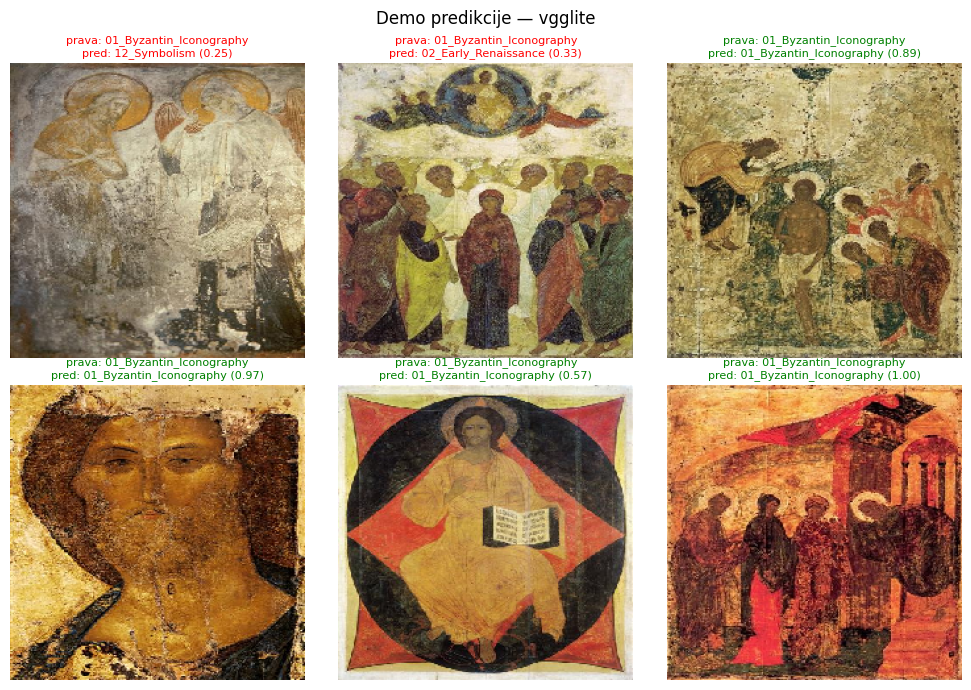

tacno u ovom batchu: 4 / 6


In [4]:
# prvih N_SHOW slika iz test skupa (shuffle=False)
batch_x, batch_y = next(test_iter)
n = min(N_SHOW, len(batch_x))
probs = model.predict(batch_x[:n], verbose=0)
pred = probs.argmax(axis=1)
true = batch_y[:n].argmax(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()
for i in range(n):
    axes[i].imshow(batch_x[i])
    ok = pred[i] == true[i]
    color = "green" if ok else "red"
    axes[i].set_title(
        f"prava: {names[true[i]]}\npred: {names[pred[i]]} ({probs[i, pred[i]]:.2f})",
        color=color,
        fontsize=8,
    )
    axes[i].axis("off")
for j in range(n, len(axes)):
    axes[j].axis("off")
fig.suptitle(f"Demo predikcije — {MODEL_NAME}")
fig.tight_layout()
plt.show()

print("tacno u ovom batchu:", int((pred == true).sum()), "/", n)

## 3. Glavne Python skripte

| Skripta | Šta radi |
|---|---|
| `src/train.py --model vgglite\|hybrid` | treniranje custom CNN |
| `src/transfer.py` | transfer / fine-tune InceptionV3 |
| `src/evaluate.py --model ...` | test metrike + confusion matrix |
| `src/plot_curves.py --model ...` | krive učenja |
| `src/plot_comparison.py` | bar chart poređenja |

Primer evaluacije bez notebooka:

```bash
python src/evaluate.py --model vgglite
python src/evaluate.py --exp-dir experiments/transfer_finetune --image-size 299
```

## 4. Matrica konfuzije (sačuvana figura)

Za najbolji model (fine-tune) — ako figura postoji lokalno.

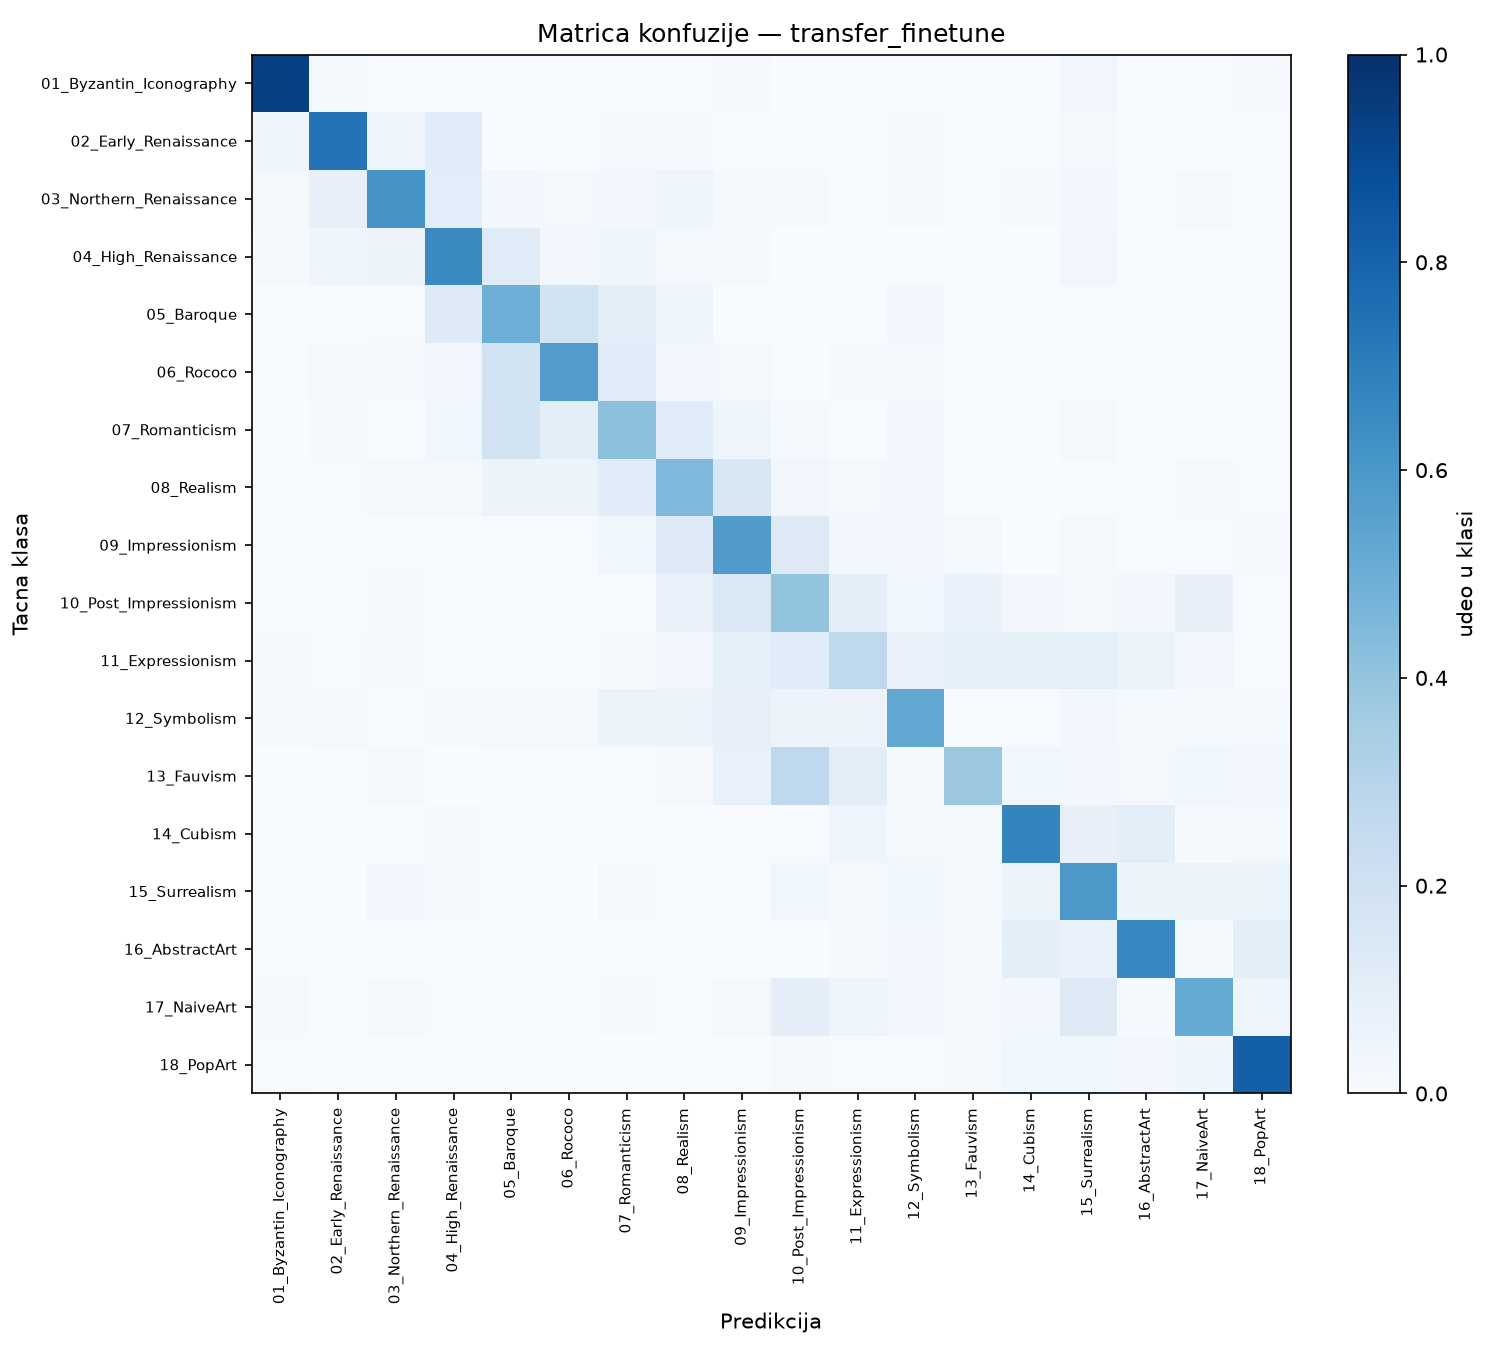

In [7]:
cm_path = ROOT / "reports" / "figures" / "transfer_finetune_confusion.png"
if cm_path.is_file():
    display(Image(filename=str(cm_path)))
else:
    # fallback na vgglite
    alt = ROOT / "reports" / "figures" / "vgglite_confusion.png"
    display(Image(filename=str(alt)))